In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
import os
from glob import glob

files = glob("../data/*.csv")

df_list = []

for file in files:
    temp = pd.read_csv(file)
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)

print(df.shape)
df.head()

(368300, 14)


,movie_id,movie_name,year,certificate,runtime,genre,rating,description,director,director_id,star,star_id,votes,gross(in $)
0,tt9114286,Black Panther: Wakanda Forever,2022,PG-13,161 min,"Action, Adventure, Drama",6.9,The people of Wakanda fight to protect their h...,Ryan Coogler,/name/nm3363032/,"Letitia Wright, \nLupita Nyong'o, \nDanai Guri...","/name/nm4004793/,/name/nm2143282/,/name/nm1775...",204835.0,NaN
1,tt1630029,Avatar: The Way of Water,2022,PG-13,192 min,"Action, Adventure, Fantasy",7.8,Jake Sully lives with his newfound family form...,James Cameron,/name/nm0000116/,"Sam Worthington, \nZoe Saldana, \nSigourney We...","/name/nm0941777/,/name/nm0757855/,/name/nm0000...",295119.0,NaN
2,tt5884796,Plane,2023,R,107 min,"Action, Thriller",6.5,A pilot finds himself caught in a war zone aft...,Jean-François Richet,/name/nm0724938/,"Gerard Butler, \nMike Colter, \nTony Goldwyn, ...","/name/nm0124930/,/name/nm1591496/,/name/nm0001...",26220.0,NaN
3,tt6710474,Everything Everywhere All at Once,2022,R,139 min,"Action, Adventure, Comedy",8.0,A middle-aged Chinese immigrant is swept up in...,"Dan Kwan, \nDaniel Scheinert",/name/nm3453283/,"Michelle Yeoh, \nStephanie Hsu, \nJamie Lee Cu...","/name/nm3215397/,/name/nm0000706/,/name/nm3513...",327858.0,NaN
4,tt5433140,Fast X,2023,NaN,NaN,"Action, Crime, Mystery",NaN,Dom Toretto and his family are targeted by the...,Louis Leterrier,/name/nm0504642/,"Vin Diesel, \nJordana Brewster, \nTyrese Gibso...","/name/nm0004874/,/name/nm0108287/,/name/nm0879...",NaN,NaN


In [ ]:
df.info()

df.describe()

df.isnull().sum()

In [3]:
df['rating'] = df['rating'].fillna(df['rating'].median())

df['votes'] = df['votes'].fillna(df['votes'].median())

df['gross(in $)'] = df['gross(in $)'].fillna(0)

In [ ]:
print("Duplicates:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

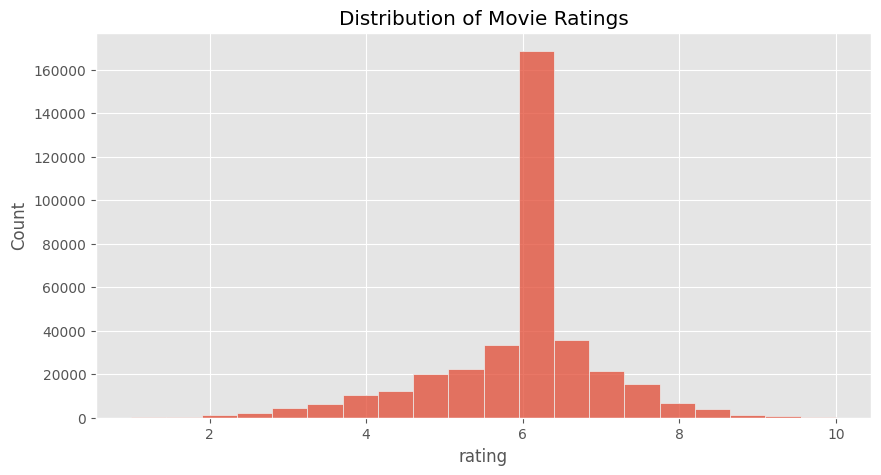

In [6]:
plt.figure(figsize=(10,5))

sns.histplot(df['rating'], bins=20)

plt.title("Distribution of Movie Ratings")

plt.show()

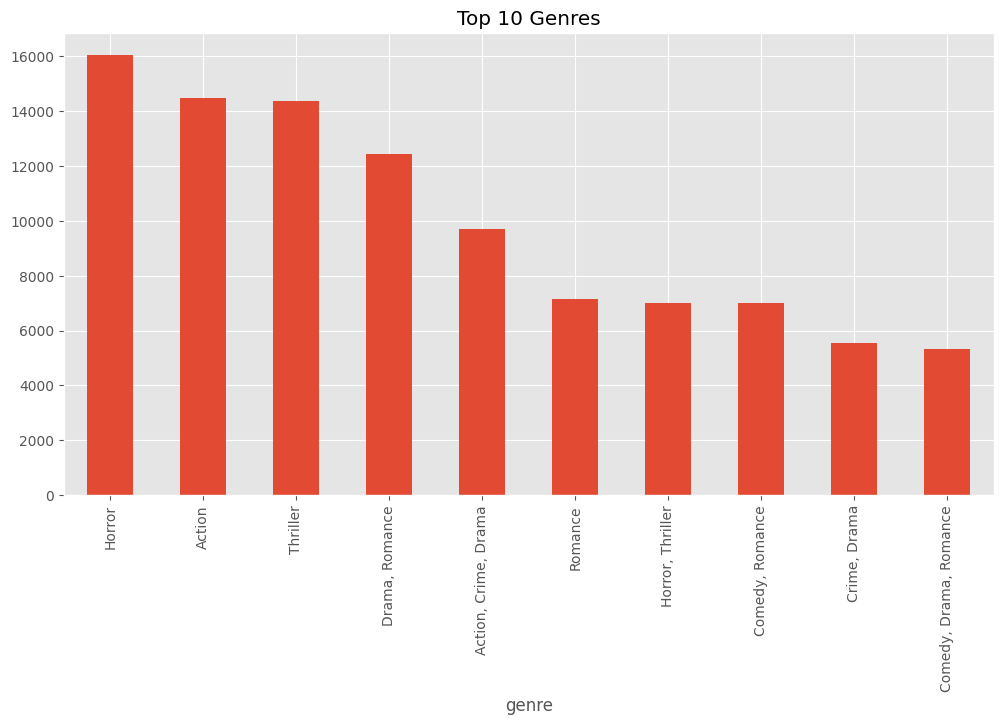

In [7]:
top_genres = df['genre'].value_counts().head(10)

plt.figure(figsize=(12,6))

top_genres.plot(kind='bar')

plt.title("Top 10 Genres")

plt.show()

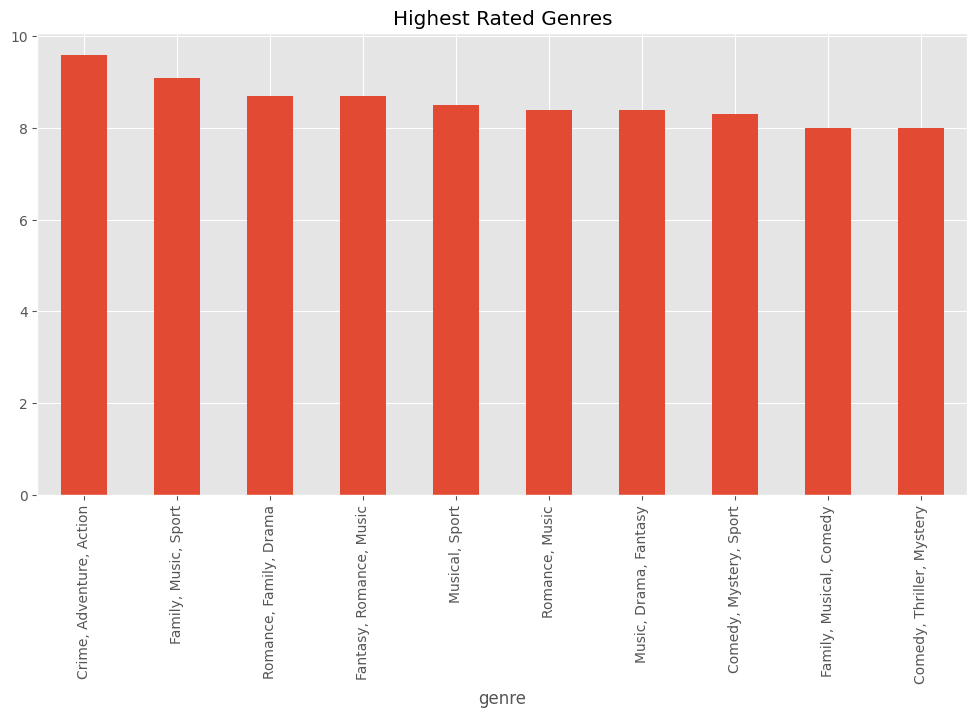

In [8]:
genre_rating = (
    df.groupby('genre')['rating']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

genre_rating.plot(kind='bar')

plt.title("Highest Rated Genres")

plt.show()

In [9]:
top_movies = df[['movie_name','rating']]

top_movies = top_movies.sort_values(
    by='rating',
    ascending=False
)

top_movies.head(10)

,movie_name,rating
25262,Love Mein,10.0
168657,Time's Paradox,10.0
167242,Journey of Eternity,10.0
15494,An Example of Teenage Boredom: The Movie,10.0
242111,Don Cutting 2,10.0
7561,Invisible Hacker,10.0
221222,The Puzzling Secret,10.0
64165,The Universal Quest,10.0
286747,Invisible Hacker,10.0
289127,Time's Paradox,10.0


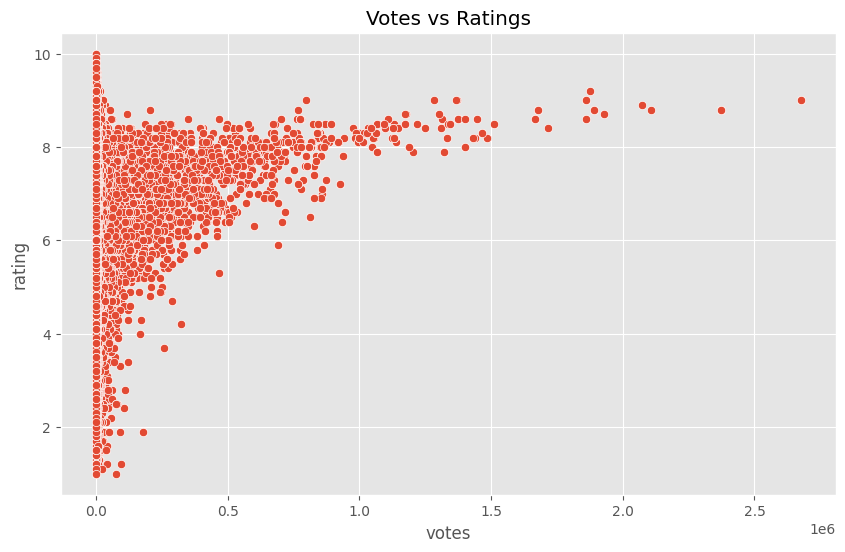

In [10]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='votes',
    y='rating'
)

plt.title("Votes vs Ratings")

plt.show()